<h1><b>Configuración y librerías

In [14]:
# Librerías
import torch
import numpy as np
import random
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet18
from copy import deepcopy
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             f1_score, recall_score, precision_score)

In [ ]:
# Rutas
DATOS_DIR = Path("../preprocesamiento/output/center_1/preprocesamiento_train")
TEST_DIR = Path("../preprocesamiento/output/center_1/preprocesamiento_test")

# Uso GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

# HIPERPARÁMETROS
BATCH_SIZE = 16      # imágenes por batch
EPOCHS     = 30      # número de épocas
LR         = 0.0004    # learning rate
VAL_SPLIT  = 0.2     # 20% para validación

Dispositivo: cuda


In [4]:
# Semilla para reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

<h1><b>Dataset

In [5]:
# P0003_S0033_STROKE.npy label = 1
# P0002_S0027_CONTROL.npy label = 0

class StrokeDataset(Dataset):

    def __init__(self, archivos):
        self.archivos = archivos

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        ruta = self.archivos[idx]

        # Cargar imagen preprocesada shape (2, 112, 112)
        imagen = np.load(ruta).astype(np.float32)
        imagen = torch.from_numpy(imagen)

        # Extraer etiqueta del nombre del archivo
        nombre = ruta.stem
        if "STROKE" in nombre:
            label = 1
        else:
            label = 0

        return imagen, torch.tensor(label, dtype=torch.float32)
    

# Verifación
todos_los_archivos = sorted(DATOS_DIR.glob("*.npy"))

print(f"Total archivos : {len(todos_los_archivos)}")

strokes   = sum(1 for f in todos_los_archivos if "STROKE"  in f.stem)
controles = sum(1 for f in todos_los_archivos if "CONTROL" in f.stem)
print(f"STROKE         : {strokes}")
print(f"CONTROL        : {controles}")

dataset_prueba = StrokeDataset(todos_los_archivos)
imagen, label  = dataset_prueba[0]
print(f"\nEjemplo cargado:")
print(f"  Shape  : {imagen.shape}")
print(f"  Label  : {label.item()} ({'STROKE' if label.item()==1 else 'CONTROL'})")

Total archivos : 3040
STROKE         : 1520
CONTROL        : 1520

Ejemplo cargado:
  Shape  : torch.Size([2, 112, 112])
  Label  : 1.0 (STROKE)


<h1><b>Split y DataLoader

In [7]:
total    = len(todos_los_archivos)
val_size = int(total * VAL_SPLIT)
train_size = total - val_size

archivos_train, archivos_val = random_split(
    todos_los_archivos,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Convertir a lista para pasarlos al Dataset
archivos_train = [todos_los_archivos[i] for i in archivos_train.indices]
archivos_val   = [todos_los_archivos[i] for i in archivos_val.indices]

# Dataset
dataset_train = StrokeDataset(archivos_train)
dataset_val   = StrokeDataset(archivos_val)

# DataLoader
loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False)

# Verificación
print(f"Train : {len(dataset_train)} muestras | {len(loader_train)} batches")
print(f"Val   : {len(dataset_val)}  muestras | {len(loader_val)} batches")

imagenes, labels = next(iter(loader_train))
print(f"\nBatch de prueba:")
print(f"  Imágenes : {imagenes.shape}")
print(f"  Labels   : {labels.shape} | {labels}")

Train : 2432 muestras | 152 batches
Val   : 608  muestras | 38 batches

Batch de prueba:
  Imágenes : torch.Size([16, 2, 112, 112])
  Labels   : torch.Size([16]) | tensor([0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1.])


<h1> <b> Modelo de entrenamiento

In [ ]:
# Qué canales importan más
class ChannelAttention(nn.Module):
    def __init__(self, canales, reduccion=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(canales, canales // reduccion),
            nn.ReLU(),
            nn.Linear(canales // reduccion, canales)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_ = self.mlp(self.max_pool(x).squeeze(-1).squeeze(-1))
        return self.sigmoid(avg + max_).unsqueeze(-1).unsqueeze(-1) * x

# Qué zonas de la imagen importan más
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        max_ = x.max(dim=1, keepdim=True).values
        mapa = torch.cat([avg, max_], dim=1)
        return self.sigmoid(self.conv(mapa)) * x


class CBAM(nn.Module):
    def __init__(self, canales):
        super().__init__()
        self.channel = ChannelAttention(canales)
        self.spatial = SpatialAttention()

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x

In [10]:
# Arquitectura ResNet-18 con CBAM
class ResNet18CBAM(nn.Module):
    def __init__(self):
        super().__init__()

        # ResNet-18 base
        base = resnet18(weights=None)

        # Primera capa: 3 canales a 2 canales
        base.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Guardamos las capas de ResNet
        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool

        self.layer1  = base.layer1
        self.layer2  = base.layer2
        self.layer3  = base.layer3
        self.layer4  = base.layer4

        # CBAM después de cada capa residual
        self.cbam1 = CBAM(64)
        self.cbam2 = CBAM(128)
        self.cbam3 = CBAM(256)
        self.cbam4 = CBAM(512)

        # Clasificador final: 1 neurona para STROKE/CONTROL
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(512, 1)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))

        x = self.cbam1(self.layer1(x))
        x = self.cbam2(self.layer2(x))
        x = self.cbam3(self.layer3(x))
        x = self.cbam4(self.layer4(x))

        x = self.avgpool(x).squeeze(-1).squeeze(-1)
        x = self.fc(x)
        return x

In [11]:
modelo = ResNet18CBAM().to(DEVICE)

# Pasar un batch de prueba
with torch.no_grad():
    salida = modelo(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo.parameters())

print(f"Entrada : {imagenes.shape}")
print(f"Salida  : {salida.shape}")
print(f"Parámetros totales: {total_params:,}")

Entrada : torch.Size([16, 2, 112, 112])
Salida  : torch.Size([16, 1])
Parámetros totales: 11,218,825


<h1><b> Entrenamiento

In [ ]:
criterio  = nn.BCEWithLogitsLoss()           # Loss para clasificación binaria
optimizer = torch.optim.AdamW(modelo.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Early stopping
PACIENCIA        = 7      # épocas sin mejora antes de parar
mejor_val_loss   = float("inf")
epocas_sin_mejora = 0
mejor_modelo     = None

# Ruta donde guardar el mejor modelo
MODELO_DIR  = Path("modelos")
MODELO_DIR.mkdir(exist_ok=True)
MODELO_PATH = MODELO_DIR / "resnet18_cbam_mejor.pth"

# Loop de entrenamiento
historial = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    # TRAIN
    modelo.train()
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        salida = modelo(imagenes)
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()

        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    # VALIDACIÓN
    modelo.eval()
    val_loss, val_correctos = 0.0, 0

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)

            salida  = modelo(imagenes)
            loss    = criterio(salida, labels)

            val_loss     += loss.item()
            preds         = (torch.sigmoid(salida) >= 0.5).float()
            val_correctos += (preds == labels).sum().item()

    # METRICAS
    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)

    historial["train_loss"].append(train_loss)
    historial["val_loss"].append(val_loss)
    historial["train_acc"].append(train_acc)
    historial["val_acc"].append(val_acc)

    scheduler.step()

    tiempo = time.time() - inicio

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"{tiempo:.1f}s")

    # GUARDAR MEJOR MODELO
    if val_loss < mejor_val_loss:
        mejor_val_loss    = val_loss
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo.state_dict())
        torch.save(mejor_modelo, MODELO_PATH)
        print(f"  ✔ Mejor modelo guardado (val_loss: {mejor_val_loss:.4f})")

    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    # EARLY STOPPING
    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_loss: {mejor_val_loss:.4f}")
print(f"Modelo guardado en: {MODELO_PATH}")

Época 01/30 | Train loss: 0.1741 acc: 0.9305 | Val loss: 0.2375 acc: 0.9309 | 61.5s
  ✔ Mejor modelo guardado (val_loss: 0.2375)
Época 02/30 | Train loss: 0.0830 acc: 0.9749 | Val loss: 0.0438 acc: 0.9885 | 7.1s
  ✔ Mejor modelo guardado (val_loss: 0.0438)
Época 03/30 | Train loss: 0.0385 acc: 0.9868 | Val loss: 0.0439 acc: 0.9852 | 7.0s
  Sin mejora 1/7
Época 04/30 | Train loss: 0.0437 acc: 0.9836 | Val loss: 0.0227 acc: 0.9885 | 7.1s
  ✔ Mejor modelo guardado (val_loss: 0.0227)
Época 05/30 | Train loss: 0.0303 acc: 0.9893 | Val loss: 0.0451 acc: 0.9918 | 7.3s
  Sin mejora 1/7
Época 06/30 | Train loss: 0.0159 acc: 0.9951 | Val loss: 0.0281 acc: 0.9918 | 7.2s
  Sin mejora 2/7
Época 07/30 | Train loss: 0.0203 acc: 0.9942 | Val loss: 0.0151 acc: 0.9951 | 7.5s
  ✔ Mejor modelo guardado (val_loss: 0.0151)
Época 08/30 | Train loss: 0.0257 acc: 0.9889 | Val loss: 0.1494 acc: 0.9638 | 7.3s
  Sin mejora 1/7
Época 09/30 | Train loss: 0.0127 acc: 0.9963 | Val loss: 0.0071 acc: 0.9967 | 7.2s
  ✔ 

<h1> <b> Evaluación

In [19]:
archivos_test = sorted(TEST_DIR.glob("*.npy"))

print(f"Total test : {len(archivos_test)}")
print(f"STROKE     : {sum(1 for f in archivos_test if 'STROKE'  in f.stem)}")
print(f"CONTROL    : {sum(1 for f in archivos_test if 'CONTROL' in f.stem)}")

# Dataset y loader
dataset_test = StrokeDataset(archivos_test)
loader_test  = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

# Cargar el mejor modelo
modelo.load_state_dict(torch.load(MODELO_PATH, map_location=DEVICE))
modelo.eval()

# Inferencia
todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo(imagenes)
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)

print("RESULTADOS — VALIDACIÓN")

print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")

Total test : 760
STROKE     : 380
CONTROL    : 380
RESULTADOS — VALIDACIÓN
  AUC-ROC       : 0.9698
  Accuracy      : 0.9342
  F1-Score      : 0.9333
  Sensibilidad  : 0.9211  (detecta STROKE)
  Especificidad : 0.9474  (detecta CONTROL)
  Precisión     : 0.9459


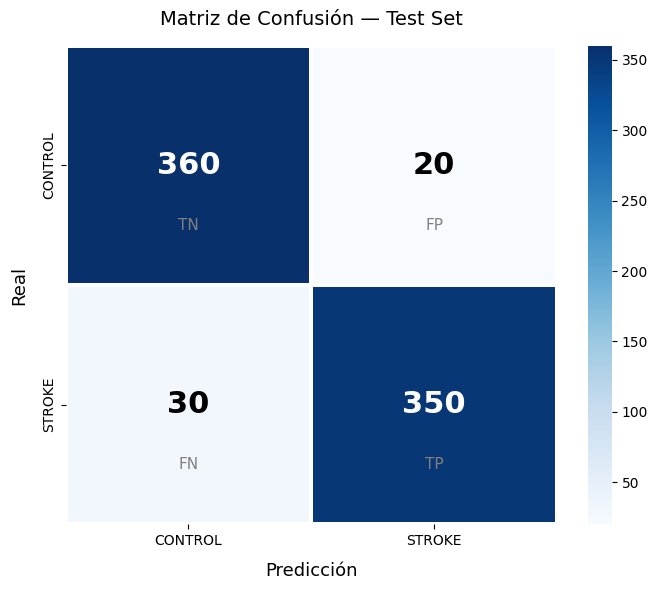

In [20]:
# Matriz de confusión
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — Test Set", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<h1><b> Entrenamiento sin CBAM

In [ ]:
class ResNet18Base(nn.Module):
    def __init__(self):
        super().__init__()

        base = resnet18(weights=None)

        # Modificamos la primera capa: 3 canales - 2 canales
        base.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool

        self.layer1  = base.layer1
        self.layer2  = base.layer2
        self.layer3  = base.layer3
        self.layer4  = base.layer4

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(512, 1)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x).squeeze(-1).squeeze(-1)
        x = self.fc(x)
        return x


# Verificación
modelo_base = ResNet18Base().to(DEVICE)

with torch.no_grad():
    salida = modelo_base(imagenes.to(DEVICE))

total_params = sum(p.numel() for p in modelo_base.parameters())
print(f"Entrada    : {imagenes.shape}")
print(f"Salida     : {salida.shape}")
print(f"Parámetros : {total_params:,}")

Entrada    : torch.Size([8, 2, 112, 112])
Salida     : torch.Size([8, 1])
Parámetros : 11,173,889


In [22]:
# ENTRENAMIENTO — ResNet18 SIN CBAM
criterio  = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(modelo_base.parameters(), lr=LR)  # ← modelo_base
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

PACIENCIA         = 7
mejor_val_loss    = float("inf")
epocas_sin_mejora = 0
mejor_modelo      = None

MODELO_PATH_BASE = MODELO_DIR / "resnet18_base_mejor.pth"  # nombre distinto

historial_base = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoca in range(EPOCHS):
    inicio = time.time()

    modelo_base.train()  # ← modelo_base
    train_loss, train_correctos = 0.0, 0

    for imagenes, labels in loader_train:
        imagenes = imagenes.to(DEVICE)
        labels   = labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        salida = modelo_base(imagenes)  # ← modelo_base
        loss   = criterio(salida, labels)
        loss.backward()
        optimizer.step()
        train_loss     += loss.item()
        preds           = (torch.sigmoid(salida) >= 0.5).float()
        train_correctos += (preds == labels).sum().item()

    modelo_base.eval()  # ← modelo_base
    val_loss, val_correctos = 0.0, 0

    with torch.no_grad():
        for imagenes, labels in loader_val:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)
            salida   = modelo_base(imagenes)  # modelo_base
            loss     = criterio(salida, labels)
            val_loss     += loss.item()
            preds         = (torch.sigmoid(salida) >= 0.5).float()
            val_correctos += (preds == labels).sum().item()

    train_loss /= len(loader_train)
    val_loss   /= len(loader_val)
    train_acc   = train_correctos / len(dataset_train)
    val_acc     = val_correctos   / len(dataset_val)

    historial_base["train_loss"].append(train_loss)
    historial_base["val_loss"].append(val_loss)
    historial_base["train_acc"].append(train_acc)
    historial_base["val_acc"].append(val_acc)

    scheduler.step()
    tiempo = time.time() - inicio

    print(f"Época {epoca+1:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
          f"{tiempo:.1f}s")

    if val_loss < mejor_val_loss:
        mejor_val_loss    = val_loss
        epocas_sin_mejora = 0
        mejor_modelo      = deepcopy(modelo_base.state_dict())
        torch.save(mejor_modelo, MODELO_PATH_BASE)
        print(f"  ✔ Mejor modelo guardado (val_loss: {mejor_val_loss:.4f})")
    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora {epocas_sin_mejora}/{PACIENCIA}")

    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nEarly stopping en época {epoca+1}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_loss: {mejor_val_loss:.4f}")
print(f"Modelo guardado en: {MODELO_PATH_BASE}")

Época 01/30 | Train loss: 0.2148 acc: 0.9132 | Val loss: 0.0895 acc: 0.9655 | 6.6s
  ✔ Mejor modelo guardado (val_loss: 0.0895)
Época 02/30 | Train loss: 0.0660 acc: 0.9794 | Val loss: 0.0630 acc: 0.9803 | 6.5s
  ✔ Mejor modelo guardado (val_loss: 0.0630)
Época 03/30 | Train loss: 0.0564 acc: 0.9803 | Val loss: 0.3501 acc: 0.8618 | 6.5s
  Sin mejora 1/7
Época 04/30 | Train loss: 0.0246 acc: 0.9918 | Val loss: 0.0485 acc: 0.9836 | 7.0s
  ✔ Mejor modelo guardado (val_loss: 0.0485)
Época 05/30 | Train loss: 0.0356 acc: 0.9881 | Val loss: 0.1495 acc: 0.9589 | 6.5s
  Sin mejora 1/7
Época 06/30 | Train loss: 0.0250 acc: 0.9914 | Val loss: 0.0972 acc: 0.9622 | 6.4s
  Sin mejora 2/7
Época 07/30 | Train loss: 0.0100 acc: 0.9967 | Val loss: 0.0229 acc: 0.9901 | 6.5s
  ✔ Mejor modelo guardado (val_loss: 0.0229)
Época 08/30 | Train loss: 0.0233 acc: 0.9922 | Val loss: 0.0118 acc: 0.9967 | 6.5s
  ✔ Mejor modelo guardado (val_loss: 0.0118)
Época 09/30 | Train loss: 0.0031 acc: 0.9996 | Val loss: 0.0

In [23]:
# Cargar el mejor modelo base
modelo_base.load_state_dict(torch.load(MODELO_PATH_BASE, map_location=DEVICE))  # ← base
modelo_base.eval()

# Inferencia
todos_labels = []
todos_probs  = []
todos_preds  = []

with torch.no_grad():
    for imagenes, labels in loader_test:
        imagenes = imagenes.to(DEVICE)
        salida   = modelo_base(imagenes)  # ← base
        probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
        preds    = (probs >= 0.5).astype(int)

        todos_labels.extend(labels.numpy().astype(int))
        todos_probs.extend(probs)
        todos_preds.extend(preds)

# Métricas
auc          = roc_auc_score(todos_labels, todos_probs)
f1           = f1_score(todos_labels, todos_preds)
sensibilidad  = recall_score(todos_labels, todos_preds)
especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
precision    = precision_score(todos_labels, todos_preds)
accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)


print(" RESULTADOS — TEST SET (Sin CBAM)")
print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Sensibilidad  : {sensibilidad:.4f}  (detecta STROKE)")
print(f"  Especificidad : {especificidad:.4f}  (detecta CONTROL)")
print(f"  Precisión     : {precision:.4f}")


 RESULTADOS — TEST SET (Sin CBAM)
  AUC-ROC       : 0.9630
  Accuracy      : 0.9184
  F1-Score      : 0.9162
  Sensibilidad  : 0.8921  (detecta STROKE)
  Especificidad : 0.9447  (detecta CONTROL)
  Precisión     : 0.9417


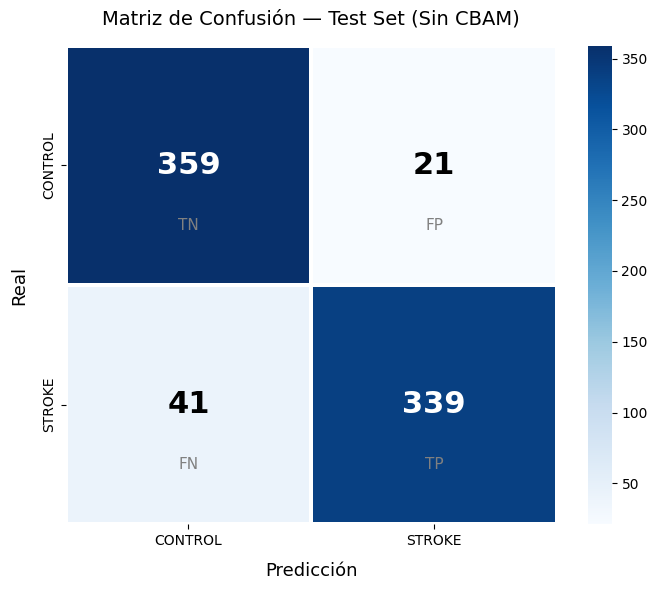

In [24]:
# Matriz de confusión
cm = confusion_matrix(todos_labels, todos_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=["CONTROL", "STROKE"],
            yticklabels=["CONTROL", "STROKE"],
            linewidths=1.5, linecolor="white", ax=ax)

for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)

etiquetas = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                ha="center", va="center",
                fontsize=11, color="gray")

ax.set_xlabel("Predicción", fontsize=13, labelpad=10)
ax.set_ylabel("Real", fontsize=13, labelpad=10)
ax.set_title("Matriz de Confusión — Test Set (Sin CBAM)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()